# Decorrelation Scale Dependences Analysis

**Purpose**: Code for explore the factors impacting of decorrelation scale estimates. Here, the focus is on the impact of record length and spectral slope. 

**Luke Colosi | lcolosi@ucsd.edu**

Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from scipy.signal import detrend
from scipy.integrate import trapezoid
from datetime import datetime, timedelta
import cmocean.cm as cmo

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from spectra import generate_powerlaw_data
from autocorr import windowed_decorrelation_scale
from plotScaleAnalysis import add_corner_label

Set plotting parameters

In [2]:
fontsize = 16
colors = ['#4c72b0', '#55a868', '#c44e52', "#b2ae72"] 
colors_decor = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

### **Section 1**: Compute decorrelation scale as a function of record length 

Set analysis parameters

In [3]:
# Set time parameters
dt = 1                # Time interval (hours)
T  = 2*365*24         # Duration of record (hours) 
N  = int(T/dt)        # Number of data points in our record
random_seed = 42      # Set random seed for reproducibility

# Set power-law parameters
alpha_ws = np.array([1, 1.5,2,3])  # Prescribed spectral slopes
n_alpha = len(alpha_ws)            # Number of spectral slopes 

# Set windowing parameters
overlap = 0.5                  # Fractional overlap between windows
min_window = 200               # Minimum window length (number of data points, 100 points ~ 4 days)
max_divisor = N // min_window  # The largest n such that N/n >= 100

# Generate divisors (fractions of the total length): 2, 3, 4, ..., max_divisor
divisors = np.arange(2, max_divisor + 1)

# Calculate window sizes directly using integer division (//) to ensure they are integers
window_sizes = N // divisors

# Filter for range (if necessary) 
window_sizes = window_sizes[window_sizes >= min_window]

# Remove duplicates
window_sizes = np.unique(window_sizes)[::-1]  # Unique and sorted largest to smallest
n_windows = len(window_sizes)  # Number of window lengths

Plot an example of a generated spectrum

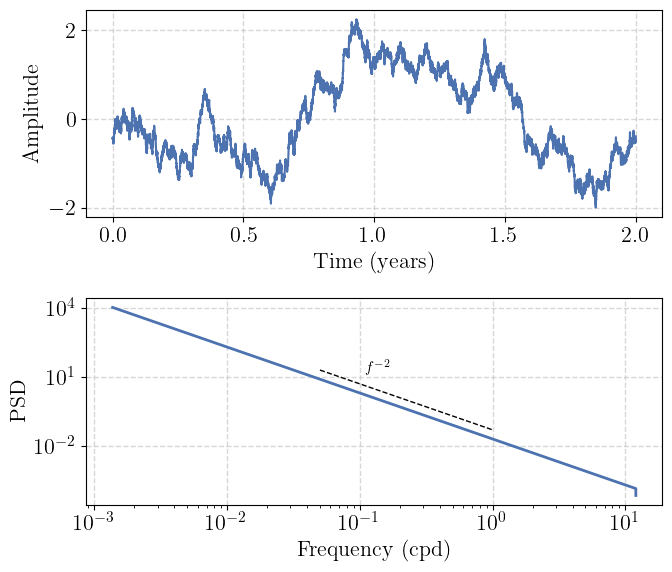

In [5]:
# Generate simulation data 
t, x, f, psd = generate_powerlaw_data(N=N, alpha=2, random_state=random_seed, dt=dt)

# Convert units of frequency and time
f_cpd = f * 24
t_year = t * (1/24)*(1/365)

# Calculate reference f^-2 line for comparison
f_ref = np.array([5*10**(-2), 10**(0)]) #np.array([10**(-4), 10**(2)])
offset = 2.5  
psd_ref = offset * (f_ref)**(-2) * psd[1] / (f_cpd[1]**(-2))  

# Create figure
fig,axes = plt.subplots(2,1,figsize=(7,6))
ax1,ax2 = axes.flatten()

#--- Subplot 1 ---# 
ax1.plot(t_year, x - np.mean(x), color=colors[0], lw=1.5)

# Set axis attributes
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Amplitude")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

#--- Subplot 2 ---# 
ax2.loglog(f_cpd[1:], psd[1:], lw=2, color=colors[0], label=r"$f^{-" + str(2) + r"}$")

# Plot an f^-2 reference line for comparison
ax2.loglog(f_ref, psd_ref, 'k--', lw=1, label=r"$f^{-2}$ reference")  

# Set axis attributes
ax2.set_xlabel("Frequency (cpd)")
ax2.set_ylabel("PSD")
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Add f^-2 label
f_text = 0.1  # Choose a frequency for the label (in cpd)
psd_text = 7 * (f_text)**(-2) * psd[1] / (f_cpd[1]**(-2))  # Calculate corresponding PSD value
ax2.text(
    f_text * 1.1,            # shift right in log space
    psd_text * 1.2,          # shift up in log space
    r"$f^{-2}$",
    fontsize=11,
    bbox=dict(
        facecolor="none",
        edgecolor="none",
        alpha=0.8
    )
)

# Display figure
plt.tight_layout()
plt.show()

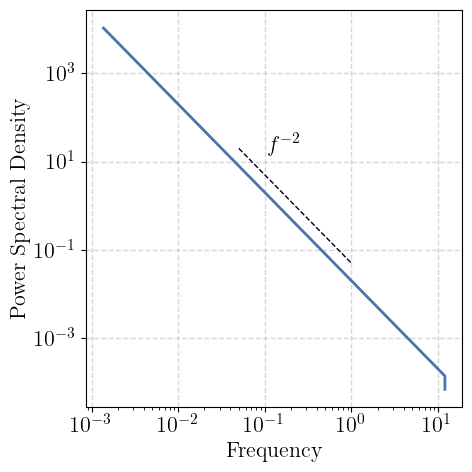

In [10]:
# Create figure
fig,ax = plt.subplots(figsize=(5,5))

# Plot spectrum 
ax.loglog(f_cpd[1:], psd[1:], lw=2, color=colors[0], label=r"$f^{-" + str(2) + r"}$")

# Plot an f^-2 reference line for comparison
ax.loglog(f_ref, psd_ref, 'k--', lw=1, label=r"$f^{-2}$ reference")  

# Set axis attributes
ax.set_xlabel("Frequency")
ax.set_ylabel("Power Spectral Density")
ax.grid(ls='--',lw=1.0,alpha=0.5)

# Add f^-2 label
f_text = 0.1  # Choose a frequency for the label (in cpd)
psd_text = 7 * (f_text)**(-2) * psd[1] / (f_cpd[1]**(-2))  # Calculate corresponding PSD value
ax.text(
    f_text * 1.1,            # shift right in log space
    psd_text * 1.2,          # shift up in log space
    r"$f^{-2}$",
    fontsize=fontsize,
    bbox=dict(
        facecolor="none",
        edgecolor="none",
        alpha=0.8
    )
)

# Display figure
plt.tight_layout()
plt.show()

Generate time series and compute decorrelation scales 

Progress: 100.0%

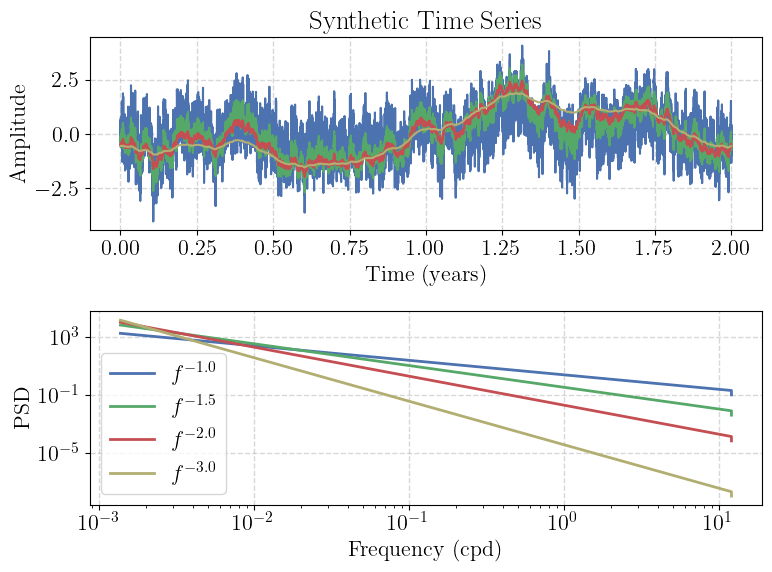

In [4]:
# Initialize arrays
Lt_av   = np.zeros((n_alpha, n_windows))
Lt_stdm = np.zeros((n_alpha, n_windows))

# Create figure
fig,axes = plt.subplots(2,1,figsize=(8,6))
ax1,ax2 = axes.flatten()

# Loop through spectral slopes
for i, ialpha in enumerate(alpha_ws):

    # Set progress bar
    progress = (i+1) / (n_alpha)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Generate simulation data 
    t, x, f, psd = generate_powerlaw_data(N=N, alpha=ialpha, random_state=random_seed, dt=dt)

    # Preform scale analysis
    scales, Lt_mean, Lt_err, _ = windowed_decorrelation_scale(x, t, dt, scales=window_sizes, norm=False, 
                                                                    overlap=overlap, return_windows=True, 
                                                                    valid_frac=0.8, detrend_option=True)
    
    # Store results 
    Lt_av[i, :]   = Lt_mean
    Lt_stdm[i, :] = Lt_err

    # Convert units of frequency and time
    f_cpd = f * 24
    t_year = t * (1/24)*(1/365)

    # Plot the ith simulated data record

    #--- Subplot 1 ---# 
    ax1.plot(t_year, x - np.mean(x), color=colors[i])

    #--- Subplot 1 ---# 
    ax2.loglog(f_cpd[1:], psd[1:], lw=2, color=colors[i], label=r"$f^{-" + str(ialpha) + r"}$")

# Set axis attributes
ax1.set_title('Synthetic Time Series')
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Amplitude")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

# Set axis attributes
ax2.set_xlabel("Frequency (cpd)")
ax2.set_ylabel("PSD")
ax2.legend()
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

Clean up decorrelation scale estimates

In [5]:
# Set zero decorrelation scales to masked data
mask = (Lt_av == 0)
Lt_av   = np.ma.array(Lt_av, mask=mask)
Lt_stdm = np.ma.array(Lt_stdm, mask=mask)

# Convert decorrelation scales to units of days and window size to months
Lt_av_days_ws = Lt_av * (1/24)
Lt_stdm_days_ws = Lt_stdm * (1/24)
window_sizes_months_ws = window_sizes / (24 * 30.44)

Plot decorrelation scale estimates

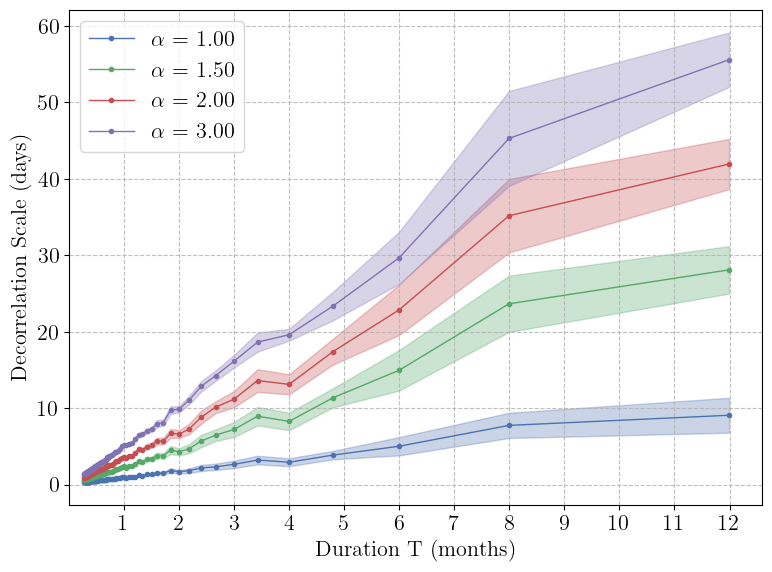

In [6]:
# Set color counter
cn = 0

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through spectral slopes
for i, alpha in enumerate(alpha_ws):
    
    # Plot just spectral slopes of 1, 1.5, 2, and 3
    if (alpha == 1) | (alpha == 1.5) | (alpha == 2) | (alpha == 3): 

        # Plot mean decorrelation scale
        ax.plot(window_sizes_months_ws, Lt_av_days_ws[i, :], '.-', color=colors_decor[cn],
                linewidth=1, label=r'$\alpha$ = {:.2f}'.format(alpha))
        
        # Plot standard error as shaded region
        ax.fill_between(window_sizes_months_ws,
                        Lt_av_days_ws[i, :] - Lt_stdm_days_ws[i, :],
                        Lt_av_days_ws[i, :] + Lt_stdm_days_ws[i, :],
                        color=colors_decor[cn], alpha=0.3)

        # Reset counter 
        cn += 1

# Set figure attributes
ax.set_xlabel('Duration T (months)')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xlim(0, np.max(window_sizes_months_ws) * 1.05)
ax.set_xticks(np.arange(1,13))
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='upper left', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

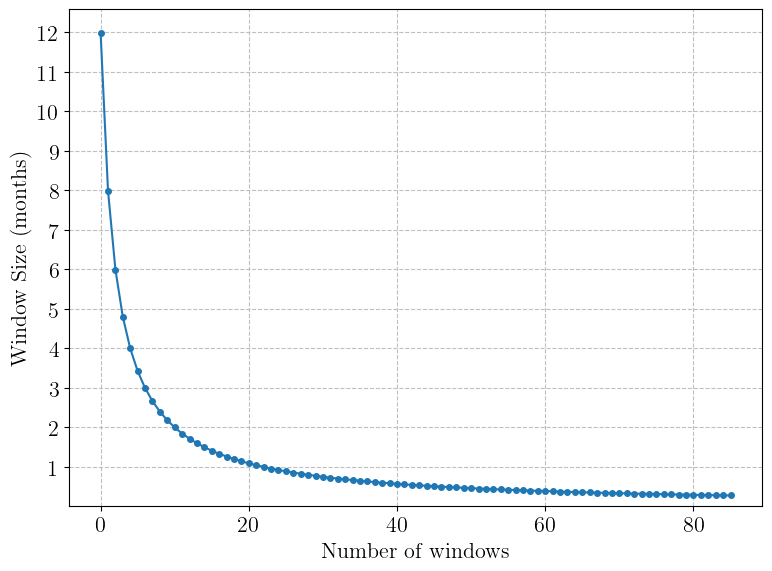

In [7]:
# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot window size vector
ax.plot(window_sizes_months_ws, '.-', color='tab:blue', linewidth=1.5, markersize=8)

# Set figure attributes
ax.set_xlabel('Number of windows')
ax.set_ylabel('Window Size (months)')
ax.set_ylim(0, np.max(window_sizes_months_ws) * 1.05)
ax.set_yticks(np.arange(1,13))
ax.grid(True,linestyle='--',alpha=0.8)

# Display figure
plt.tight_layout()
plt.show()

### **Section 2**: Compute decorrelation scale as a function of spectral slope

Set analysis parameters

In [5]:
# Set time parameters
dt = 1                # Time interval (hours)
T  = 2*365*24         # Duration of record (hours) 
N  = int(T/dt)        # Number of data points in our record
random_seed = 42      # Set random seed for reproducibility

# Set power-law parameters
alphas_as = np.arange(0,5 + 0.1,0.1)  # Prescribed spectral slopes
n_alpha = len(alphas_as)              # Number of spectral slopes

# Set windowing parameters
overlap = 0.5                                                 # Fractional overlap between windows
window_sizes = np.int64(np.array([3, 6, 8, 12]) * 30.44* 24)  # Units: Hours (or number of data points in the record)
n_windows = len(window_sizes)

Generate time series and compute decorrelation scales 

In [6]:
# Initialize arrays
Lt_av   = np.zeros((n_alpha, n_windows))
Lt_stdm = np.zeros((n_alpha, n_windows))

# Loop through spectral slopes
for i, ialpha in enumerate(alphas_as):

    # Set progress bar
    progress = (i+1) / (len(alphas_as))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Generate fake data 
    t, x, f, psd = generate_powerlaw_data(N=N, alpha=ialpha, random_state=random_seed, dt=dt)

    # Preform scale analysis
    scales, Lt_mean, Lt_err, _ = windowed_decorrelation_scale(x, t, dt, scales=window_sizes, norm=False, 
                                                                    overlap=overlap, return_windows=True,
                                                                    valid_frac=0.8, detrend_option=True)
    
    # Store results (Lt_mean and Lt_std are 1D arrays of length n_windows)
    Lt_av[i, :]   = Lt_mean
    Lt_stdm[i, :] = Lt_err

# Set zero decorrelation scales to masked data
mask = (Lt_av == 0)
Lt_av   = np.ma.array(Lt_av, mask=mask)
Lt_stdm = np.ma.array(Lt_stdm, mask=mask)

# Convert decorrelation scales to units of days and window size to months
Lt_av_days_as = Lt_av * (1/24)
Lt_stdm_days_as = Lt_stdm * (1/24)
window_sizes_months_as = window_sizes / (24 * 30.44)

Progress: 100.0%

Plot the results

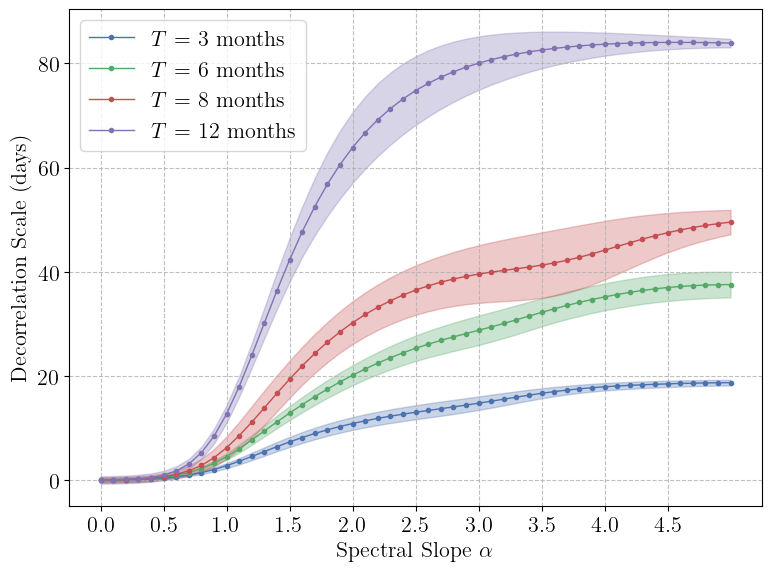

In [5]:
# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through window sizes
for i, window in enumerate(window_sizes_months_as):

    # Plot mean decorrelation scale
    ax.plot(alphas_as, Lt_av_days_as[:,i], '.-', color=colors_decor[i],
            linewidth=1, label=r'$T$ = {:.0f} months'.format(window))
    
    # Plot standard error as shaded region
    ax.fill_between(alphas_as,
                     Lt_av_days_as[:,i] - Lt_stdm_days_as[:,i],
                     Lt_av_days_as[:,i] + Lt_stdm_days_as[:,i],
                     color=colors_decor[i], alpha=0.3)

# Set figure attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks(np.arange(0,5,0.5))
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='upper left', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

Combine plots into a single figure

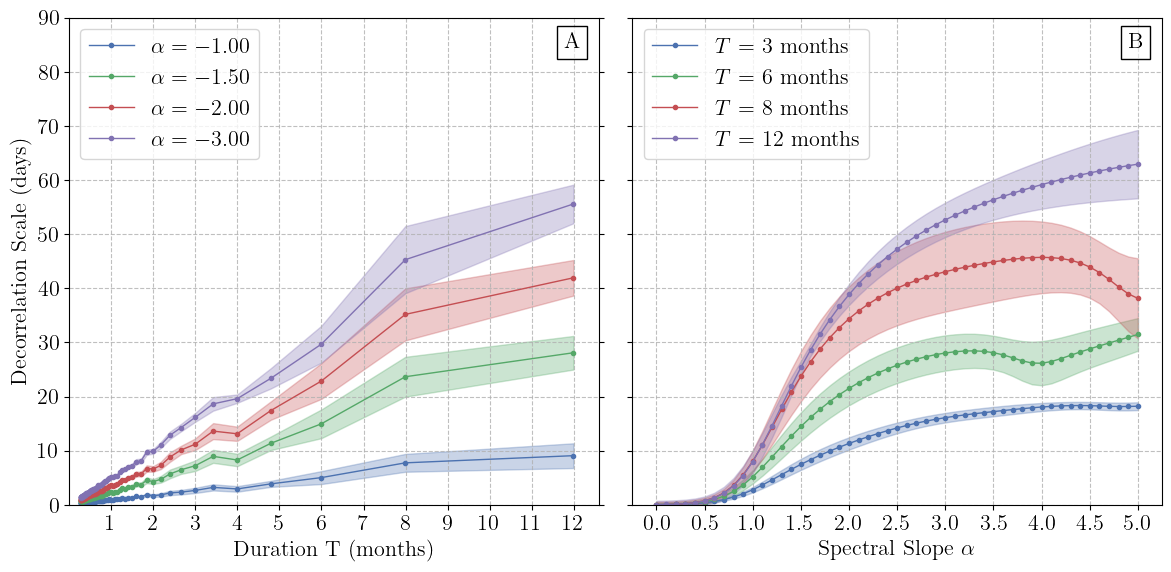

In [11]:
# Set color counter
cn = 0

# Create the figure
fig, axes = plt.subplots(1,2, figsize=(12, 6))
ax1,ax2 = axes.flatten()

#--- Subplot 2 ---# 

# Loop through spectral slopes
for i, alpha in enumerate(alpha_ws):
    
    # Plot just spectral slopes of 1, 1.5, 2, and 3
    if (alpha == 1) | (alpha == 1.5) | (alpha == 2) | (alpha == 3) | (alpha == 3): 

        # Plot mean decorrelation scale
        ax1.plot(window_sizes_months_ws, Lt_av_days_ws[i, :], '.-', color=colors_decor[cn],
                linewidth=1, label=r'$\alpha = -${:.2f}'.format(alpha))
        
        # Plot standard error as shaded region
        ax1.fill_between(window_sizes_months_ws,
                        Lt_av_days_ws[i, :] - Lt_stdm_days_ws[i, :],
                        Lt_av_days_ws[i, :] + Lt_stdm_days_ws[i, :],
                        color=colors_decor[cn], alpha=0.3)

        # Reset counter 
        cn += 1

# Set figure attributes
ax1.set_xlabel('Duration T (months)')
ax1.set_ylabel(r'Decorrelation Scale (days)')
ax1.set_xlim(0, np.max(window_sizes_months_ws) * 1.05)
ax1.set_xticks(np.arange(1,13))
ax1.set_yticks(np.arange(0,90 + 10,10))
ax1.set_ylim(0,90)
ax1.grid(True,linestyle='--',alpha=0.8)
ax1.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.legend(loc='upper left', fontsize=fontsize)

#--- Subplot 2 ---# 

# Loop through window sizes
for i, window in enumerate(window_sizes_months_as):

    # Plot mean decorrelation scale
    ax2.plot(alphas_as, Lt_av_days_as[:,i], '.-', color=colors_decor[i],
            linewidth=1, label=r'$T$ = {:.0f} months'.format(window))
    
    # Plot standard error as shaded region
    ax2.fill_between(alphas_as,
                     Lt_av_days_as[:,i] - Lt_stdm_days_as[:,i],
                     Lt_av_days_as[:,i] + Lt_stdm_days_as[:,i],
                     color=colors_decor[i], alpha=0.3)

# Set figure attributes
ax2.set_xlabel(r'Spectral Slope $\alpha$')
ax2.set_xticks(np.arange(0,5+0.5,0.5))
ax2.set_yticks(np.arange(0,90 + 10,10))
ax2.set_yticklabels([])
ax2.set_ylim(0,90)
ax2.grid(True,linestyle='--',alpha=0.8)
ax2.tick_params(top=False, bottom=True, left=True, right=False,
            direction='out', length=3.5)
ax2.legend(loc='upper left', fontsize=fontsize)

# Label each subplot
pos = [0.95, 0.95]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)

# Display figure
plt.tight_layout()
plt.show()

# # Save with high quality
# figName = 'figS04.png'
# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )

### **Section 3**: Compute decorrelation scale as a function of both record length and spectral slope

Set analysis parameters

In [12]:
# Set time parameters
dt = 1                # Time interval (hours)
T  = 2*365*24         # Duration of record (hours) 
N  = int(T/dt)        # Number of data points in our record
random_seed = 42      # Set random seed for reproducibility

# Set power-law parameters
alpha = np.arange(0,5 + 0.1,0.1)  # Prescribed spectral slopes
n_alpha = len(alpha)            # Number of spectral slopes 

# Set windowing parameters
overlap = 0.5                  # Fractional overlap between windows
min_window = 300               # Minimum window length (number of data points, 100 points ~ 4 days)
max_divisor = N // min_window  # The largest n such that N/n >= 100

# Generate divisors (fractions of the total length): 2, 3, 4, ..., max_divisor
divisors = np.arange(2, max_divisor + 1)

# Calculate window sizes directly using integer division (//) to ensure they are integers
window_sizes = N // divisors

# Filter for range (if necessary) 
window_sizes = window_sizes[window_sizes >= min_window]

# Remove duplicates
window_sizes = np.unique(window_sizes)[::-1]  # Unique and sorted largest to smallest
n_windows = len(window_sizes)  # Number of window lengths

Generate time series and compute decorrelation scales 

In [13]:
# Initialize arrays
Lt_av   = np.zeros((n_alpha, n_windows))
Lt_stdm = np.zeros((n_alpha, n_windows))

# Loop through spectral slopes
for i, ialpha in enumerate(alpha):

    # Set progress bar
    progress = (i+1) / (n_alpha)
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Generate simulation data 
    t, x, f, psd = generate_powerlaw_data(N=N, alpha=ialpha, random_state=random_seed, dt=dt)

    # Preform scale analysis
    scales, Lt_mean, Lt_err, _ = windowed_decorrelation_scale(x, t, dt, scales=window_sizes, norm=False, 
                                                                    overlap=overlap, return_windows=True, 
                                                                    valid_frac=0.8, detrend_option=True)
    
    # Store results 
    Lt_av[i, :]   = Lt_mean
    Lt_stdm[i, :] = Lt_err

    # Convert units of frequency and time
    f_cpd = f * 24
    t_year = t * (1/24)*(1/365)

Progress: 100.0%

Clean up decorrelation estimate and window sizes

In [14]:
# Set zero decorrelation scales to masked data
mask = (Lt_av == 0)
Lt_av   = np.ma.array(Lt_av, mask=mask)
Lt_stdm = np.ma.array(Lt_stdm, mask=mask)

# Convert decorrelation scales to units of days and window size to months
Lt_av_days = Lt_av * (1/24)
Lt_stdm_days = Lt_stdm * (1/24)
window_sizes_months = window_sizes / (24 * 30.44)

Plot decorrelation scale as a function of record length and spectral slope 

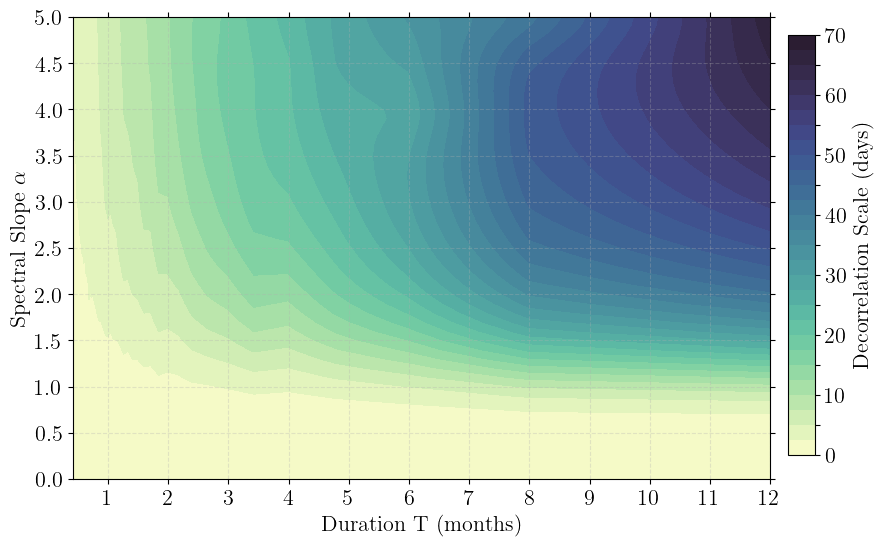

In [15]:
# Set plotting parameters
levels = np.arange(0, 70 + 2.5, 2.5)

# Create the figure
fig, ax = plt.subplots(1,1, figsize=(9, 6))

# Plot decorrelation scale
cn = ax.contourf(window_sizes_months, alpha, Lt_av_days, levels=levels, cmap=cmo.deep)

# Set figure attributes
ax.set_xlabel('Duration T (months)')
ax.set_ylabel(r'Spectral Slope $\alpha$')
ax.set_xticks(np.arange(1,13))
ax.set_yticks(np.arange(0,5+0.5,0.5))
ax.grid(True,linestyle='--',alpha=0.3)
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
               direction='out', which='both', length=3.5)

# Set colorbar 
cax = fig.add_axes([0.92, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cn, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Decorrelation Scale (days)', fontsize=fontsize)
cbar.mappable.set_clim(0, 70)
ticks = np.arange(0, 70+5, 5)
cbar.set_ticks(ticks)
labels = [f'{val}' if i % 2 == 0 else '' for i, val in enumerate(ticks)]
cbar.set_ticklabels(labels)

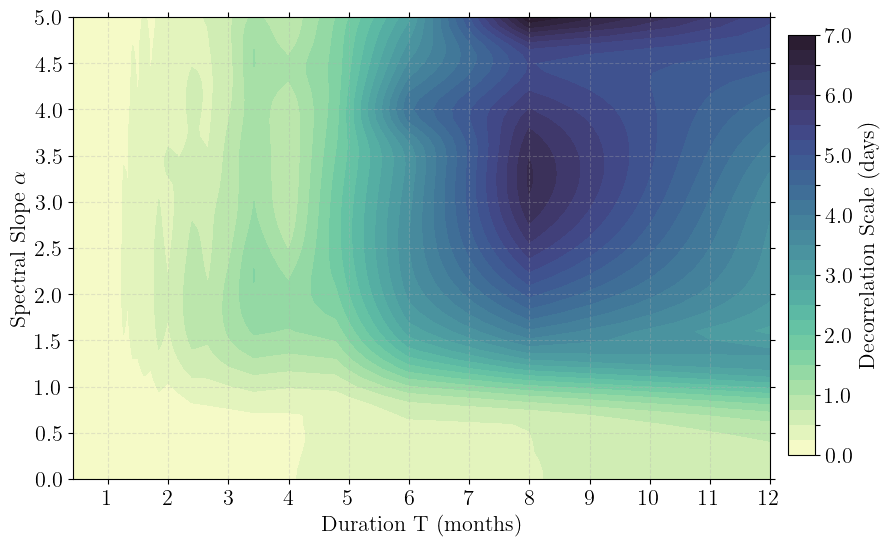

In [23]:
# Set plotting parameters
levels = np.arange(0, 7 + 0.25, 0.25)

# Create the figure
fig, ax = plt.subplots(1,1, figsize=(9, 6))

# Plot decorrelation scale
cn = ax.contourf(window_sizes_months, alpha, Lt_stdm_days, levels=levels, cmap=cmo.deep)

# Set figure attributes
ax.set_xlabel('Duration T (months)')
ax.set_ylabel(r'Spectral Slope $\alpha$')
ax.set_xticks(np.arange(1,13))
ax.set_yticks(np.arange(0,5+0.5,0.5))
ax.grid(True,linestyle='--',alpha=0.3)
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
               direction='out', which='both', length=3.5)

# Set colorbar 
cax = fig.add_axes([0.92, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cn, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Decorrelation Scale (days)', fontsize=fontsize)
cbar.mappable.set_clim(0, 7)
ticks = np.arange(0, 7+0.5, 0.5)
cbar.set_ticks(ticks)
labels = [f'{val}' if i % 2 == 0 else '' for i, val in enumerate(ticks)]
cbar.set_ticklabels(labels)

Combine all the figures together

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_28071/469270986.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


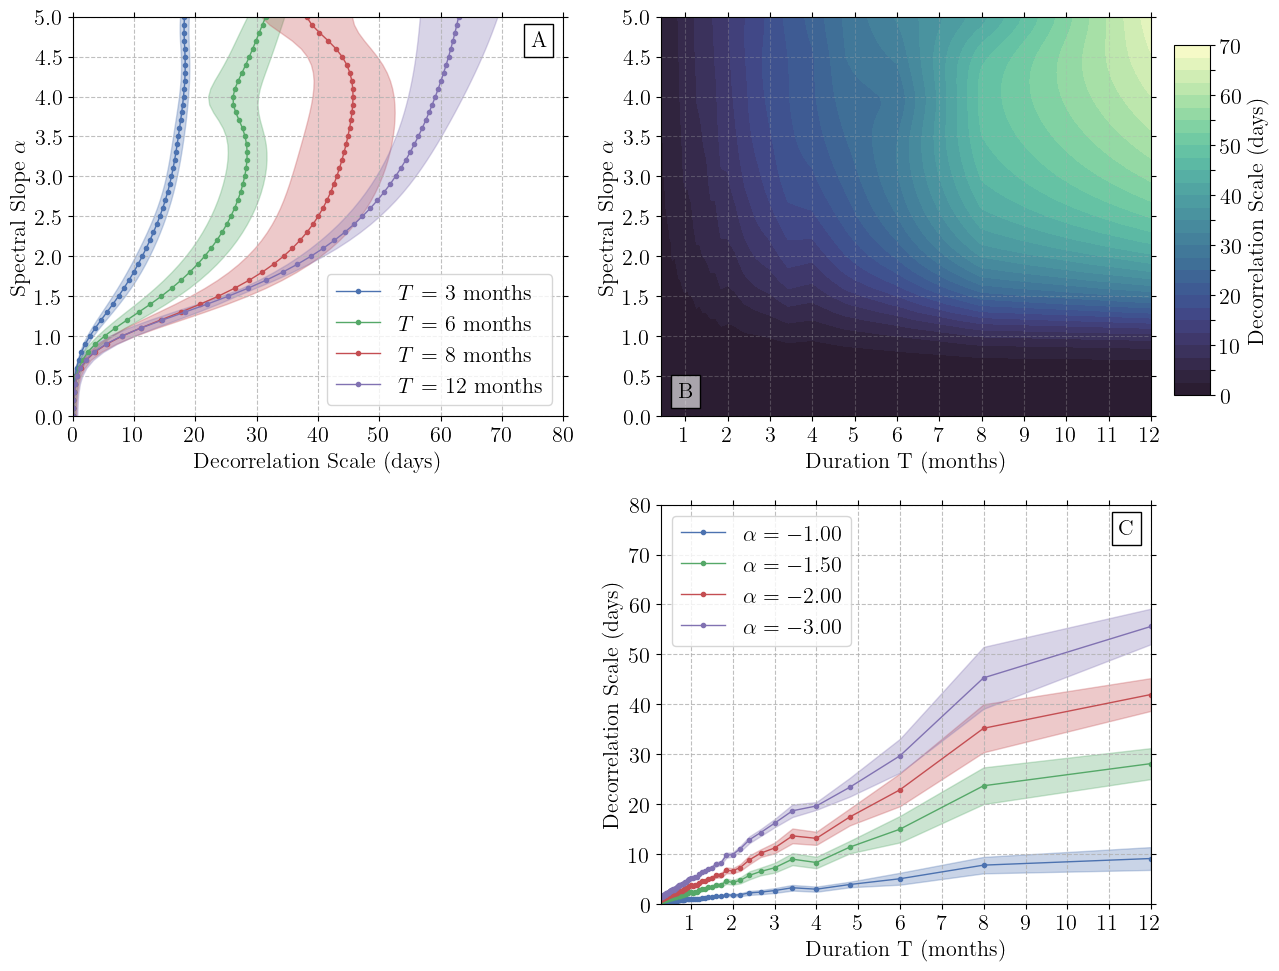

In [18]:
# Set plotting parameters
levels = np.arange(0, 70 + 2.5, 2.5)
cn = 0

# Create figure
fig,axes = plt.subplots(2,2,figsize=(12, 10))
ax1,ax2,ax3,ax4 = axes.flatten()

#--- Subplot 1 ---# 

# Loop through window sizes
for i, window in enumerate(window_sizes_months_as):

    # Plot mean decorrelation scale
    ax1.plot(Lt_av_days_as[:,i], alphas_as, '.-', color=colors_decor[i],
            linewidth=1, label=r'$T$ = {:.0f} months'.format(window))
    
    # Plot standard error as shaded region
    ax1.fill_betweenx(alphas_as,
                     Lt_av_days_as[:,i] - Lt_stdm_days_as[:,i],
                     Lt_av_days_as[:,i] + Lt_stdm_days_as[:,i],
                     color=colors_decor[i], alpha=0.3)

# Set figure attributes
ax1.set_xlabel('Decorrelation Scale (days)')
ax1.set_xticks(np.arange(0,80 + 10,10))
ax1.set_xlim(0,80)
ax1.set_ylabel(r'Spectral Slope $\alpha$')
ax1.set_yticks(np.arange(0,5+0.5,0.5))
ax1.set_ylim(0,5)
ax1.grid(True,linestyle='--',alpha=0.8)
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.legend(loc='lower right', fontsize=fontsize)

#--- Subplot 2 ---# 

# Plot decorrelation scale
pc = ax2.contourf(window_sizes_months, alpha, Lt_av_days, levels=levels, cmap=cmo.deep_r)

# Set figure attributes
ax2.set_xlabel('Duration T (months)')
ax2.set_ylabel(r'Spectral Slope $\alpha$')
ax2.set_xticks(np.arange(1,13))
ax2.set_yticks(np.arange(0,5+0.5,0.5))
ax2.grid(True,linestyle='--',alpha=0.3)
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
               direction='out', which='both', length=3.5)

# Set colorbar 
cax = fig.add_axes([0.99, 0.59, 0.03, 0.35])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Decorrelation Scale (days)', fontsize=fontsize)
cbar.mappable.set_clim(0, 70)
ticks = np.arange(0, 70+5, 5)
cbar.set_ticks(ticks)
labels = [f'{val}' if i % 2 == 0 else '' for i, val in enumerate(ticks)]
cbar.set_ticklabels(labels)

#--- Subplot 3 ---# 
ax3.axis('off')

#--- Subplot 4 ---# 

# Loop through spectral slopes
for i, ialpha in enumerate(alpha_ws):
    
    # Plot just spectral slopes of 1, 1.5, 2, and 3
    if (ialpha == 1) | (ialpha == 1.5) | (ialpha == 2) | (ialpha == 3): 

        # Plot mean decorrelation scale
        ax4.plot(window_sizes_months_ws, Lt_av_days_ws[i, :], '.-', color=colors_decor[cn],
                linewidth=1, label=r'$\alpha = -${:.2f}'.format(ialpha))
        
        # Plot standard error as shaded region
        ax4.fill_between(window_sizes_months_ws,
                        Lt_av_days_ws[i, :] - Lt_stdm_days_ws[i, :],
                        Lt_av_days_ws[i, :] + Lt_stdm_days_ws[i, :],
                        color=colors_decor[cn], alpha=0.3)

        # Reset counter 
        cn += 1

# Set figure attributes
ax4.set_xlabel('Duration T (months)')
ax4.set_ylabel(r'Decorrelation Scale (days)')
ax4.set_xlim(np.min(window_sizes_months_ws), np.max(window_sizes_months_ws))
ax4.set_xticks(np.arange(1,13))
ax4.set_yticks(np.arange(0,80 + 10,10))
ax4.set_ylim(0,80)
ax4.grid(True,linestyle='--',alpha=0.8)
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.legend(loc='upper left', fontsize=fontsize)

# Label each subplot
pos = [0.95, 0.94]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, [0.05,0.06], 'B', fontsize = fontsize)
add_corner_label(ax4, pos, 'C', fontsize = fontsize)

# Adjust spacing
plt.tight_layout()
plt.show()